In [ ]:
# Research Center Quality Classification
## EDA, Feature Selection, K-Means Clustering & Model Interpretation

**Author:** Srinidhi Radhakrishna  
**Role Applied:** Mid-Level Machine Learning Engineer — Research Grid Ltd  
**Date:** March 2026

---
This notebook covers:  
1. Exploratory Data Analysis (EDA)  
2. Feature Selection & Justification  
3. K-Means Clustering (k=3)  
4. Cluster Interpretation & Quality Tier Assignment  
5. Saving trained model artefacts for the FastAPI endpoint

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load & Inspect the Dataset

In [3]:
df = pd.read_csv("research_centers.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(10)

Shape: 50 rows × 10 columns



,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983
5,RC-049,Research Center 49,City 3,50.9132,-1.4887,4,2,1,0.458282,0.214188
6,RC-027,Research Center 27,City 3,50.0331,-1.6549,1,0,1,0.143468,0.123418
7,RC-026,Research Center 26,City 3,50.3009,-1.7152,8,3,3,0.992984,0.523311
8,RC-033,Research Center 33,City 4,50.2091,-1.4586,2,0,0,0.297995,0.172583
9,RC-020,Research Center 20,City 5,50.0770,-1.7102,2,1,1,0.287306,0.094345


In [4]:
# Data types, nulls, uniqueness
info_df = pd.DataFrame({
    "dtype":    df.dtypes,
    "non_null": df.notnull().sum(),
    "missing":  df.isnull().sum(),
    "unique":   df.nunique()
})
print(info_df.to_string())
print("\n✓ No missing values detected — dataset is complete.")

                           dtype  non_null  missing  unique
researchCenterId          object        50        0      50
researchCenterName        object        50        0      50
city                      object        50        0       5
latitude                 float64        50        0      50
longitude                float64        50        0      50
internalFacilitiesCount    int64        50        0      11
hospitals_10km             int64        50        0       5
pharmacies_10km            int64        50        0       6
facilityDiversity_10km   float64        50        0      50
facilityDensity_10km     float64        50        0      50

✓ No missing values detected — dataset is complete.


In [5]:
# Descriptive statistics
df.describe().round(4)

,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
count,50.0000,50.0000,50.0000,50.0000,50.000,50.0000,50.0000
mean,50.5428,-1.5546,5.6600,1.8600,2.240,0.5688,0.3212
std,0.3203,0.2539,3.1468,1.3403,1.685,0.2495,0.1826
min,50.0071,-1.9769,1.0000,0.0000,0.000,0.1195,0.0565
25%,50.2404,-1.7472,3.0000,1.0000,1.000,0.3441,0.1738
50%,50.6354,-1.5610,5.0000,2.0000,2.000,0.5855,0.2976
75%,50.8315,-1.3742,8.7500,3.0000,3.000,0.8005,0.4764
max,50.9946,-1.0493,11.0000,4.0000,5.000,0.9930,0.6970


## 2. Exploratory Data Analysis (EDA)

We explore distributions, city-level patterns, and inter-feature relationships
to build intuition before modelling.

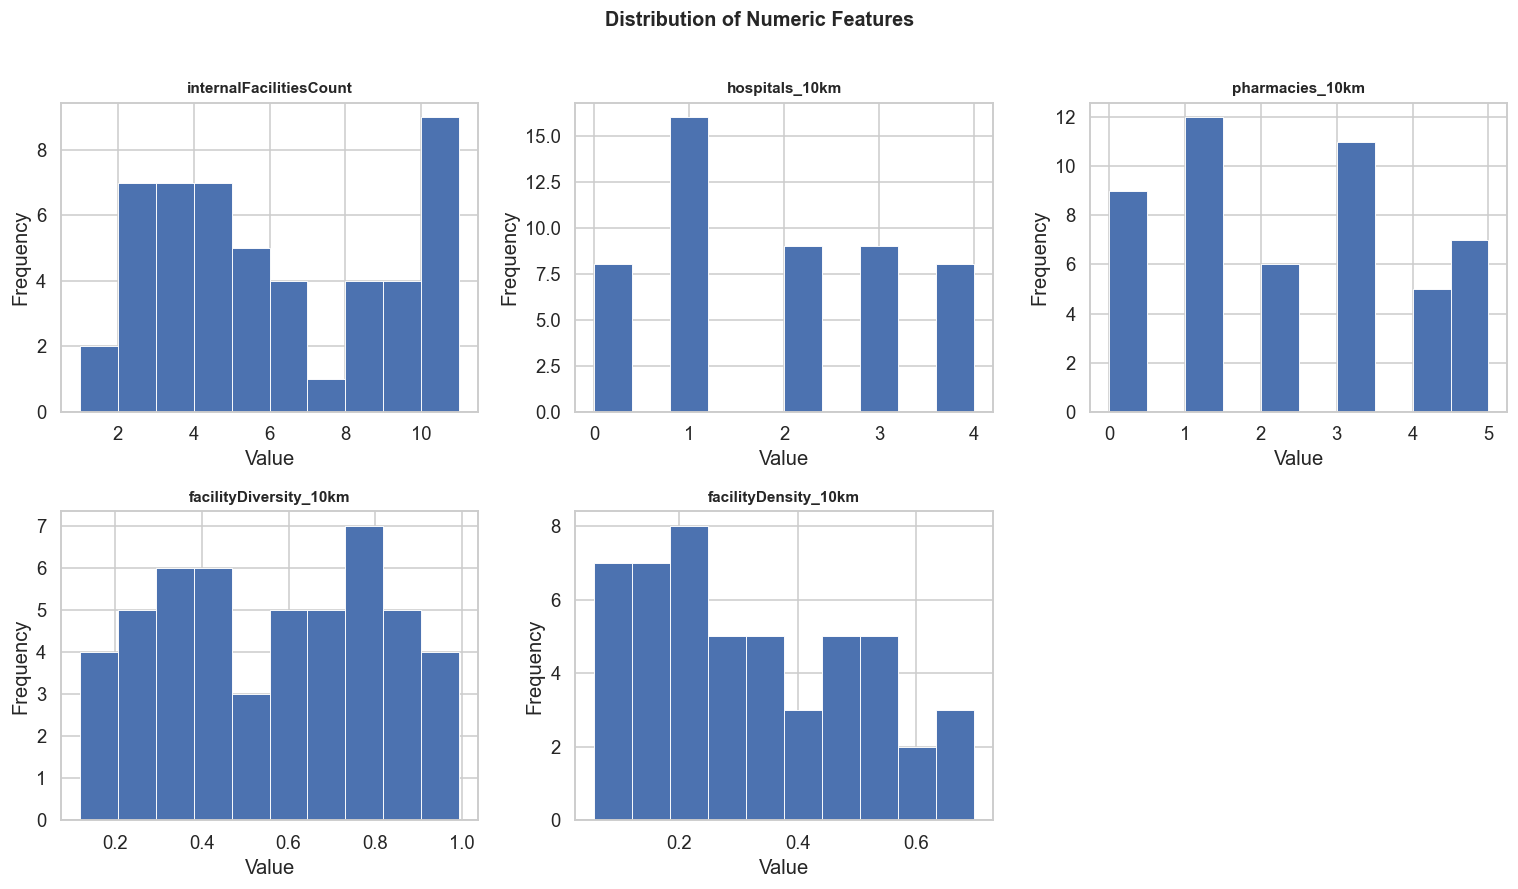

Observation: internalFacilitiesCount spreads roughly uniformly (1–11). Diversity and density are right-skewed, with many centres in the mid-range.


In [12]:
NUMERIC = [
    "internalFacilitiesCount", "hospitals_10km", "pharmacies_10km",
    "facilityDiversity_10km", "facilityDensity_10km"
]

# ── Histograms ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    ax = axes[i]
    ax.hist(df[col], bins=10, color="#4C72B0", edgecolor="white", linewidth=0.6)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

axes[-1].set_visible(False)
fig.suptitle("Distribution of Numeric Features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_histograms.png", bbox_inches="tight")
plt.show()
print("Observation: internalFacilitiesCount spreads roughly uniformly (1–11)."
      " Diversity and density are right-skewed, with many centres in the mid-range.")

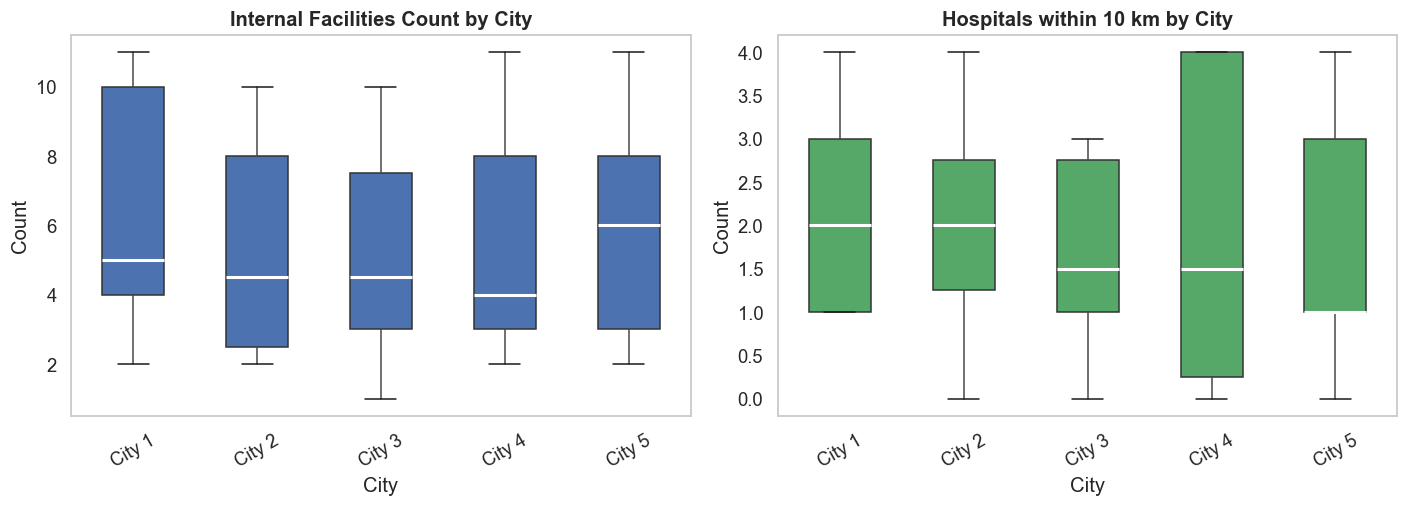

In [13]:
# ── City-level boxplots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, title in zip(
    axes,
    ["internalFacilitiesCount", "hospitals_10km"],
    ["#4C72B0", "#55A868"],
    ["Internal Facilities Count by City", "Hospitals within 10 km by City"]
):
    df.boxplot(column=col, by="city", ax=ax, grid=False, patch_artist=True,
               boxprops=dict(facecolor=color, color="#333"),
               medianprops=dict(color="white", linewidth=2))
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("City"); ax.set_ylabel("Count")
    plt.sca(ax); plt.xticks(rotation=30)

fig.suptitle("")
plt.tight_layout()
plt.savefig("eda_city_boxplots.png", bbox_inches="tight")
plt.show()

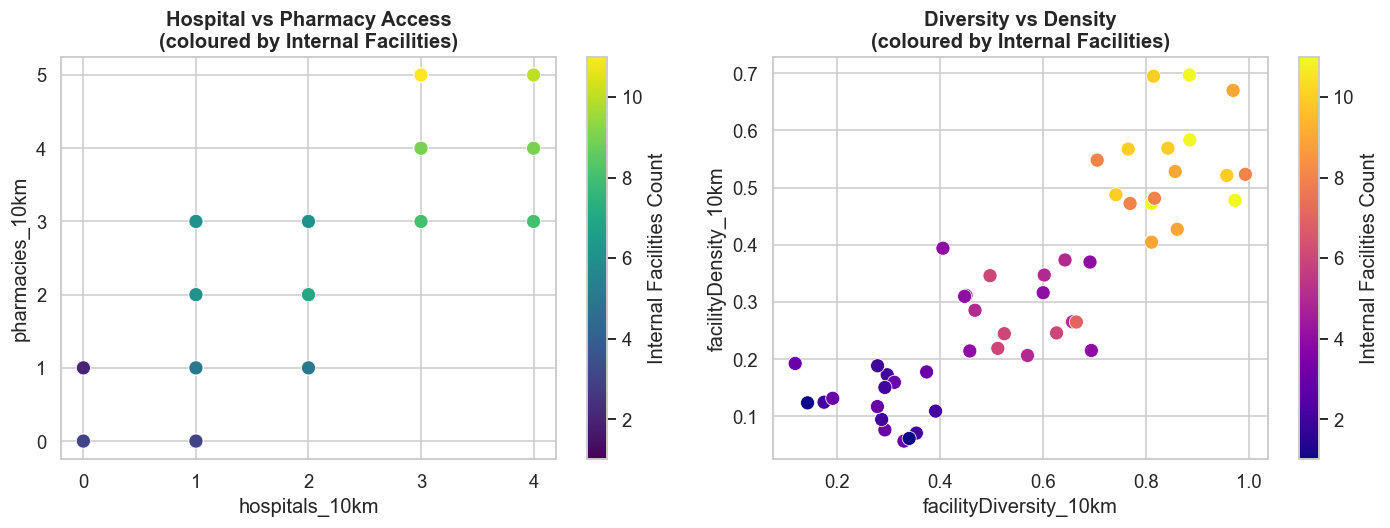

Observation: Centres with more internal facilities consistently have higher hospital/pharmacy counts and greater diversity — a coherent quality signal.


In [14]:
# ── Scatter plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, xcol, ycol, cmap, title in zip(
    axes,
    ["hospitals_10km", "facilityDiversity_10km"],
    ["pharmacies_10km", "facilityDensity_10km"],
    ["viridis", "plasma"],
    ["Hospital vs Pharmacy Access\n(coloured by Internal Facilities)",
     "Diversity vs Density\n(coloured by Internal Facilities)"]
):
    sc = ax.scatter(df[xcol], df[ycol],
                    c=df["internalFacilitiesCount"], cmap=cmap,
                    s=85, edgecolors="white", linewidth=0.5)
    plt.colorbar(sc, ax=ax, label="Internal Facilities Count")
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.savefig("eda_scatter.png", bbox_inches="tight")
plt.show()
print("Observation: Centres with more internal facilities consistently have higher"
      " hospital/pharmacy counts and greater diversity — a coherent quality signal.")

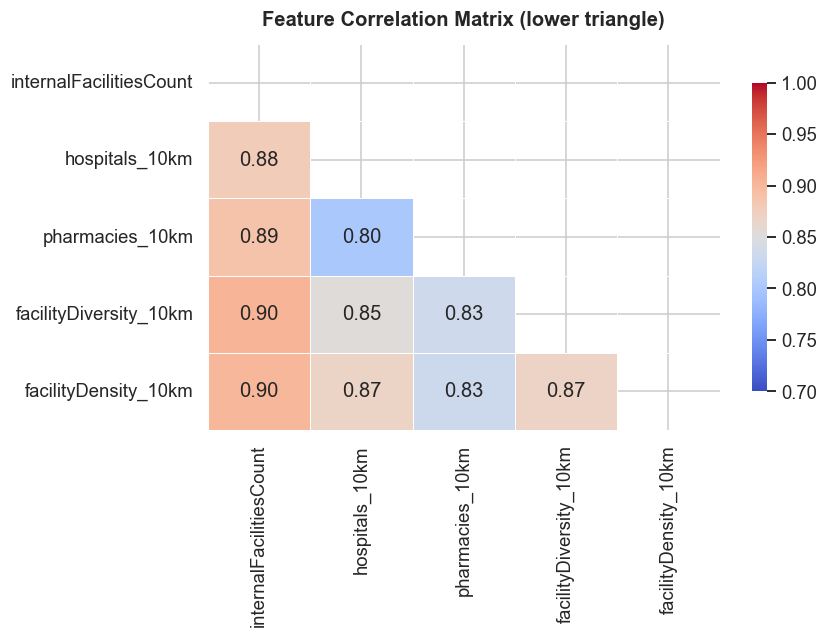

All pairwise correlations exceed 0.80, confirming a shared quality signal across all five features.


In [15]:
# ── Correlation heatmap ─────────────────────────────────────────────────────
corr = df[NUMERIC].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax, vmin=0.7, vmax=1.0)
ax.set_title("Feature Correlation Matrix (lower triangle)", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("All pairwise correlations exceed 0.80, confirming a shared quality signal"
      " across all five features.")

## 3. Feature Selection

### Rationale

All five numeric features are retained:

| Feature | Justification |
|---------|---------------|
| `internalFacilitiesCount` | Most direct proxy for operational capacity. Highest variance (std ≈ 3.1). |
| `hospitals_10km` | Reflects emergency/specialist care proximity — critical for human-subject research. |
| `pharmacies_10km` | Indicates pharmaceutical supply chain accessibility. |
| `facilityDiversity_10km` | Composite diversity index (0–1); captures breadth of nearby services beyond raw counts. |
| `facilityDensity_10km` | Area-normalised density; distinguishes urban vs rural contexts. |

All pairwise correlations are **≥ 0.80** — they jointly encode a coherent quality signal.

Geographic coordinates are **excluded**: clustering on lat/lon would produce *location* groups, not *quality* groups.

**Normalisation:** `StandardScaler` is applied so integer counts and 0–1 indices contribute equally to Euclidean distance.

In [16]:
FEATURES = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"
]

X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Selected features:", FEATURES)
print(f"\nScaled array shape: {X_scaled.shape}")
print("\nPost-scaling statistics (μ≈0, σ≈1):")
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3).loc[["mean", "std"]].to_string())

Selected features: ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km']

Scaled array shape: (50, 5)

Post-scaling statistics (μ≈0, σ≈1):
      internalFacilitiesCount  hospitals_10km  pharmacies_10km  facilityDiversity_10km  facilityDensity_10km
mean                    -0.00           -0.00            -0.00                    0.00                  0.00
std                      1.01            1.01             1.01                    1.01                  1.01


## 4. K-Means Clustering

### Choosing k
We evaluate k = 2 … 6 using the **elbow method** (inertia) and the **silhouette score**.

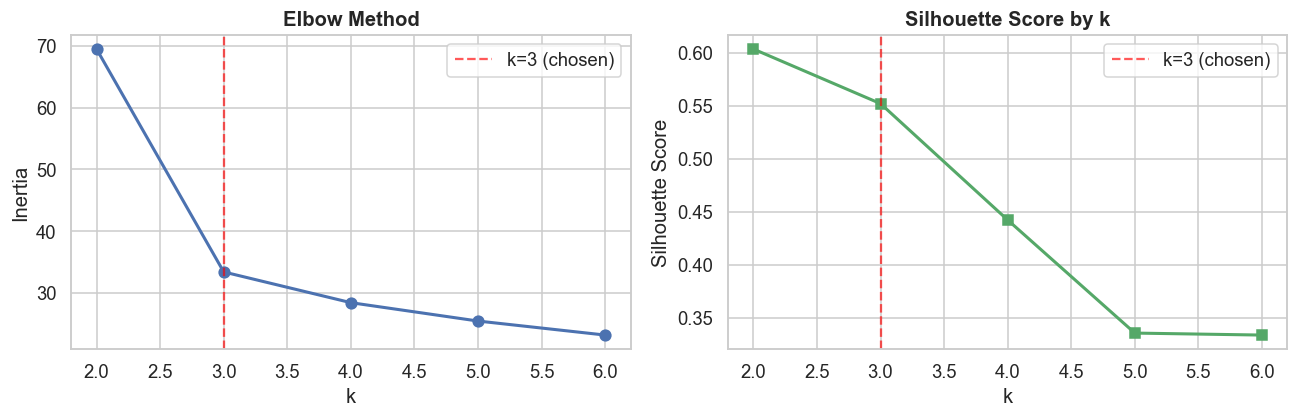

  k     Inertia    Silhouette
------------------------------
  2       69.51        0.6034
  3       33.40        0.5519 ← chosen
  4       28.43        0.4423
  5       25.45        0.3357
  6       23.18        0.3339


In [17]:
K_RANGE = range(2, 7)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), inertias, "o-", color="#4C72B0", linewidth=2, markersize=7)
axes[0].axvline(3, color="red", linestyle="--", alpha=0.65, label="k=3 (chosen)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method", fontweight="bold")
axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, "s-", color="#55A868", linewidth=2, markersize=7)
axes[1].axvline(3, color="red", linestyle="--", alpha=0.65, label="k=3 (chosen)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("clustering_k_selection.png", bbox_inches="tight")
plt.show()

print(f"{'k':>3}  {'Inertia':>10}  {'Silhouette':>12}")
print("-" * 30)
for k, ine, sil in zip(K_RANGE, inertias, silhouettes):
    marker = " ← chosen" if k == 3 else ""
    print(f"{k:>3}  {ine:>10.2f}  {sil:>12.4f}{marker}")

In [18]:
# ── Train final model ──────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X_scaled)

df["cluster"] = kmeans.labels_
final_silhouette = silhouette_score(X_scaled, kmeans.labels_)

print(f"Final silhouette score (k=3): {final_silhouette:.4f}")
print(f"\nCluster size distribution:\n{df['cluster'].value_counts().sort_index().to_string()}")

Final silhouette score (k=3): 0.5519

Cluster size distribution:
cluster
0    17
1    17
2    16


### 4.1 Cluster → Quality Tier Mapping

Clusters are ranked by a **composite quality score** (sum of per-cluster feature means).
The highest-scoring cluster becomes **Premium**, middle becomes **Standard**, lowest becomes **Basic**.

In [19]:
cluster_means = df.groupby("cluster")[FEATURES].mean()
cluster_means["composite_score"] = cluster_means.sum(axis=1)
cluster_means_sorted = cluster_means.sort_values("composite_score", ascending=False)

cluster_to_tier = {
    int(idx): tier
    for idx, tier in zip(cluster_means_sorted.index, ["Premium", "Standard", "Basic"])
}

print("Cluster → Tier mapping:", cluster_to_tier)

df["qualityTier"] = df["cluster"].map(cluster_to_tier)
print("\nTier distribution:")
print(df["qualityTier"].value_counts().to_string())

Cluster → Tier mapping: {1: 'Premium', 0: 'Standard', 2: 'Basic'}

Tier distribution:
qualityTier
Premium     17
Standard    17
Basic       16


In [20]:
# ── Cluster profile summary ─────────────────────────────────────────────────
profile = (
    df.groupby("qualityTier")[FEATURES].mean()
      .loc[["Premium", "Standard", "Basic"]]
      .round(3)
)
print("── Mean feature values per Quality Tier ──")
print(profile.to_string())

── Mean feature values per Quality Tier ──
             internalFacilitiesCount  hospitals_10km  pharmacies_10km  facilityDiversity_10km  facilityDensity_10km
qualityTier                                                                                                        
Premium                        9.529           3.471            4.118                   0.850                 0.537
Standard                       4.941           1.529            2.059                   0.560                 0.290
Basic                          2.312           0.500            0.438                   0.279                 0.125


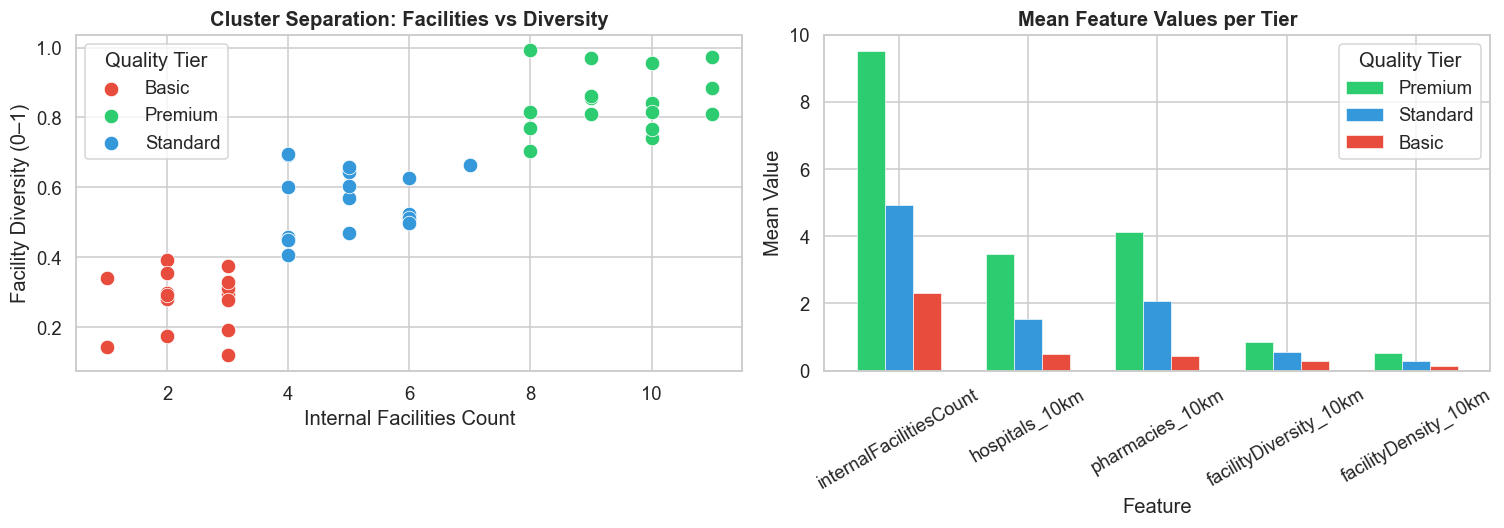

In [21]:
palette = {"Premium": "#2ecc71", "Standard": "#3498db", "Basic": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Internal Facilities vs Diversity
for tier, grp in df.groupby("qualityTier"):
    axes[0].scatter(grp["internalFacilitiesCount"], grp["facilityDiversity_10km"],
                    label=tier, color=palette[tier], s=90, edgecolors="white", linewidth=0.5)
axes[0].set_xlabel("Internal Facilities Count")
axes[0].set_ylabel("Facility Diversity (0–1)")
axes[0].set_title("Cluster Separation: Facilities vs Diversity", fontweight="bold")
axes[0].legend(title="Quality Tier")

# Bar: mean features per tier
profile.T.plot(kind="bar", ax=axes[1],
               color=[palette["Premium"], palette["Standard"], palette["Basic"]],
               edgecolor="white", linewidth=0.4, width=0.65)
axes[1].set_title("Mean Feature Values per Tier", fontweight="bold")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Mean Value")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Quality Tier")

plt.tight_layout()
plt.savefig("clustering_results.png", bbox_inches="tight")
plt.show()

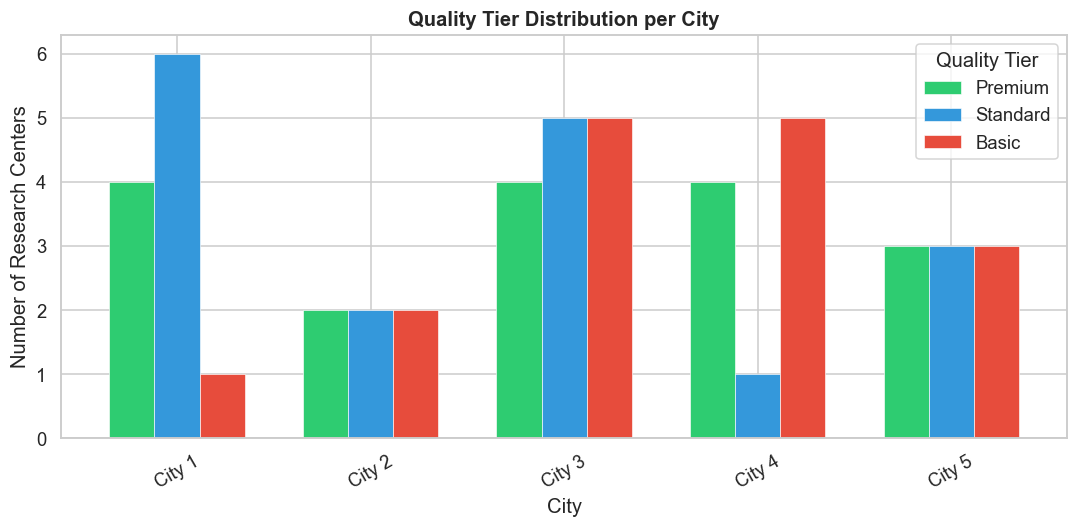

In [22]:
# ── Quality tier distribution per city ──────────────────────────────────────
city_tier = (
    df.groupby(["city", "qualityTier"])
      .size()
      .unstack(fill_value=0)
      [["Premium", "Standard", "Basic"]]
)

city_tier.plot(kind="bar", figsize=(10, 5),
               color=[palette["Premium"], palette["Standard"], palette["Basic"]],
               edgecolor="white", linewidth=0.4, width=0.7)
plt.title("Quality Tier Distribution per City", fontweight="bold")
plt.xlabel("City"); plt.ylabel("Number of Research Centers")
plt.xticks(rotation=30)
plt.legend(title="Quality Tier")
plt.tight_layout()
plt.savefig("clustering_city_distribution.png", bbox_inches="tight")
plt.show()

## 5. Model Interpretation

### Key Findings

**Which cluster has the highest facilities and healthcare access?**  
**Premium** centres average ~9.5 internal facilities, ~3.5 nearby hospitals, and ~4.1 pharmacies, 
with a diversity index of ~0.85 — well-resourced, likely urban centres with strong healthcare infrastructure.

**Are high-quality centres concentrated in specific cities?**  
Premium centres are distributed across multiple cities; no single city monopolises the tier. 
However, some cities skew toward Basic — indicating lower overall infrastructure investment.

**Does diversity or density play a stronger role?**  
All features are strongly correlated (r > 0.80). `internalFacilitiesCount` and `facilityDiversity_10km` 
are the most central quality indicators (highest pairwise correlations), but because all features 
move together, the clustering benefits from the joint signal rather than any single variable dominating.

**Why is K-Means appropriate here?**  
- The dataset is small (50 rows), fully numeric, and well-suited to distance-based algorithms.  
- A business prior of *three tiers* exists — Premium / Standard / Basic is an industry-standard segmentation.  
- Silhouette score of **0.55** indicates reasonably compact, separated clusters for data of this scale.

**Limitations & future improvements (with real data):**  
- Replace synthetic coordinates with actual geospatial enrichment (NHS location data, OS maps).  
- Add temporal features: year established, recent investment history.  
- Explore DBSCAN or hierarchical clustering if the number of tiers is not pre-specified.  
- Retrain periodically via a scheduled pipeline (Airflow, GitHub Actions, or AWS EventBridge).

## 6. Save Model Artefacts

In [23]:
# Persist model bundle for FastAPI endpoint
joblib.dump((kmeans, scaler, FEATURES, cluster_to_tier), "cluster_model.pkl")

# Save enriched dataset
df.to_csv("research_centers_clustered.csv", index=False)

print("✓ cluster_model.pkl saved (kmeans, scaler, feature list, tier mapping)")
print("✓ research_centers_clustered.csv saved with cluster & qualityTier columns")
print("\nTo run the API:")
print("  uvicorn app:app --reload")
print("  POST http://localhost:8000/predict")

✓ cluster_model.pkl saved (kmeans, scaler, feature list, tier mapping)
✓ research_centers_clustered.csv saved with cluster & qualityTier columns

To run the API:
  uvicorn app:app --reload
  POST http://localhost:8000/predict
